## Interior point method

In [55]:
import numpy as np
import pandas as pd
import copy as copy
import scipy
import scipy.io
import time
import os
from scipy.linalg import solve, LinAlgWarning
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import random

from matplotlib.animation import FuncAnimation, PillowWriter
import openpyxl
import xlsxwriter

import importlib
import inpoint_methods
import graph_functions
importlib.reload(graph_functions)

from inpoint_methods import paso_intpoint, loadProblem, intpoint, intpointR, highlight_greaterthan #,intpointR_mask
from graph_functions import analyze_components, graph_selected_components_trajectory, graph_mu_vs_z_one_component_static, find_components_tending_to_zero

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [13]:
def solve_catch(K,ld):
    with warnings.catch_warnings(record=True) as warneo:
        warnings.simplefilter("always", LinAlgWarning)
        # Solve the linear system
        w_vector = scipy.linalg.solve(K, ld)
        
        # Check if any warning was triggered
        if any(issubclass(warn.category, LinAlgWarning) for warn in warneo):
            # Print the warning message for all warnings captured
            for warn in warneo:
                print(f"Warning: {warn.message}")
    return w_vector

def highlight_df(mu, z, Q, k, tau, highlighted_df, mudf, perc_mu, perc_z, epsilon=1e-5, comp_tol=1e-5):
    # Previous μ from mudf
    prev_mu = mudf.loc[k-1].values
    
    # Only consider indices where μ*z <= comp_tol
    mask = mu * z <= comp_tol
    
    # Highlight if μ did not increase significantly and μ*z is small enough
    highlighted_rows = [i for i in range(len(mu)) 
                    if mask[i] and mu[i] <= prev_mu[i] + epsilon and perc_z[i] > -0.03]
    #highlighted_rows = [i for i in range(len(mu)) if mask[i] and mu[i] <= prev_mu[i] + epsilon]
    
    # Build row of 1s and 0s
    highlighted_row = [1 if i in highlighted_rows else 0 for i in range(Q.shape[0])]
    
    # Store in DataFrame
    highlighted_df.loc[k] = highlighted_row
    return highlighted_df

def display_highlights(highlighted_df,regression_df):
    # Take last 3 iterations
    last_3_iterations = highlighted_df.tail(3)
    
    # Columns consistently highlighted (1 in all last 3 iterations)
    highlighted_columns = last_3_iterations.columns[(last_3_iterations == 1).all(axis=0)].tolist()
    highlighted_columns = [int(x) for x in highlighted_columns]  # ensure ints
    print("Consistently highlighted in last 3 iterations:", highlighted_columns)
    print("Consistently highlighted in last 3 iterations:", highlighted_columns)
    print("How many in percentage of mu's dimension? ", (len(highlighted_columns)/p)*100,"%")
    #print("How many?=", len(highlighted_columns))
    
    # Columns that were highlighted in previous iteration but regressed this iteration (1 → 0)
    regressed_columns = []
    if len(highlighted_df) >= 2:
        prev_iter = highlighted_df.iloc[-2]
        last_iter = highlighted_df.iloc[-1]
        regressed_columns = prev_iter.index[(prev_iter == 1) & (last_iter == 0)].tolist()
        regressed_columns = [int(x) for x in regressed_columns]
        if regressed_columns:
            print(f"WARNING: Iter {highlighted_df.index[-1]} regressed columns (1 -> 0):", regressed_columns)

            highlighted_df_regressed = highlighted_df.tail(10)[regressed_columns]
            display(highlighted_df_regressed)
        iter_idx = highlighted_df.index[-1]
        if regression_df is not None:
                row = pd.Series(0, index=highlighted_df.columns)
                row[regressed_columns] = 1
                regression_df.loc[iter_idx] = row
    
    return highlighted_columns, regressed_columns


def progress_summary_df_clean_simple(metrics_before, metrics_after=None):
    """
    Build a progress summary DataFrame.

    If metrics_after is provided → Before vs After comparison.
    If metrics_after is None → Only show the IPM metrics.
    """

    summary_data = {
        "Metric": [],
        "Before": []
    }

    if metrics_after is not None:
        summary_data["After"] = []
        summary_data["Improved?"] = []

    for metric in metrics_before:
        before = metrics_before[metric]

        summary_data["Metric"].append(metric)
        summary_data["Before"].append(before)

        if metrics_after is not None:
            after = metrics_after[metric]
            summary_data["After"].append(after)
            summary_data["Improved?"].append(after < before)

    summary_df = pd.DataFrame(summary_data)

    return summary_df

def build_reduced_system(Q, AT, FT, U, A, F, Z, mu, x, lamda, c, b, d, tau, highlighted_columns):
    """
    Builds the full KKT system M and a reduced system M1 by eliminating
    rows/columns corresponding to highlighted indices.
    
    Returns:
        M      : full KKT system
        M1     : reduced KKT system (square)
        U1     : filtered diagonal of mu for reduced system
        ld1    : reduced RHS vector
    """
    # Dimensions
    n = Q.shape[0]
    m = A.shape[0]
    p = U.shape[0]

    # ────────── Build full system ──────────
    r1 = np.hstack((Q, AT, -FT @ U))
    r2 = np.hstack((A, np.zeros((m, m + p))))
    r3 = np.hstack((-U @ F, np.zeros((p, m)), -Z @ U))

    M = np.vstack((r1, r2, r3))   # full KKT system

    # ────────── Filter mu ──────────
    active_indices = [i for i in range(p) if i not in highlighted_columns]
    mu_filtered = mu[active_indices]
    U1 = np.diag(mu_filtered)

    # ────────── Build reduced system ──────────
    rows_to_remove = [i + (n + m) for i in highlighted_columns]  # only the μ rows
    M1 = np.delete(M, rows_to_remove, axis=0)
    M1 = np.delete(M1, rows_to_remove, axis=1)

    if M1.shape[0] != M1.shape[1]:
        raise ValueError("M1 is not square! Check highlighted indices.")

    # ────────── Build reduced RHS vector ──────────
    ld_full = np.concatenate((
        Q @ x + AT @ lamda - FT @ mu + c,   # dual residual
        A @ x - b,                          # primal residual
        U @ (d - F @ x) + tau               # complementarity row
    ))

    ld1 = np.delete(ld_full, rows_to_remove, axis=0)

    print(f"Deleted {len(rows_to_remove)} rows/columns. M1 shape: {M1.shape}")

    return M, M1, U1, ld1

def load_lp_problem(mat_file: str):
    """
    Loads a linear/quadratic problem from a .mat file and initializes
    the problem matrices for the interior-point algorithm.
    
    Returns:
        Q : ndarray    Quadratic matrix (identity by default)
        c : ndarray    Linear term vector
        A : ndarray    Equality constraint matrix
        b : ndarray    Equality constraint RHS
        F : ndarray    Inequality constraint matrix (identity by default)
        d : ndarray    Inequality constraint RHS (zeros)
        H : dict       Raw data loaded from the .mat file
    """
    print(f"Loading problem from: {mat_file}")
    H = loadProblem(f"mat_files/{mat_file}")

    # Quadratic term: identity (can be changed if needed)
    Q = np.eye(H['c'].shape[0])

    # Linear term
    c = H['c'].ravel()  # flatten in case it's a column vector

    # Equality constraints
    A = H['AE']
    b = H['bE'].ravel()  # flatten in case it's a column vector

    # Compute percentage of zeros in b
    num_zeros_b = np.sum(b == 0)
    pct_zeros_b = 100 * num_zeros_b / len(b)
    
    # Inequality constraints (x >= 0 by default)
    F = np.eye(H['c'].shape[0])
    d = np.zeros(H['c'].shape[0])

    print(f"Problem loaded. n={Q.shape[0]}, m={A.shape[0]}, p={F.shape[0]}")
    #print(f"Equality RHS b: {b}")
    print(f"Number of zeros in b: {num_zeros_b} ({pct_zeros_b:.2f}%)")

    return Q, c, A, b, F, d, H



Load problem

In [ ]:
#mat_files = 'lp_kb2.mat'     # b = 0
#mat_files = 'lp_afiro.mat'   # bmax = 500, and no mu tends to zero  and no condition problem
#mat_files = 'lp_blend.mat'    # bmax = 26.32, and no mu tends to zero.
#mat_files = 'lp_fit1d.mat'   # b = 0
#mat_files = 'lp_fit1p.mat'   # bmax = 216, and no mu tends to zero, condition 10^12
#mat_files = 'lp_grow15.mat'  # b = 0, condition 10^6
#mat_files = 'lp_grow22.mat'  # b = 0, condition 1.4e7
#mat_files = 'lp_grow7.mat'   # b = 0, condition 1.2e7

print(mat_files)

H = loadProblem(f"mat_files/{mat_files}")

# Define the quadratic matrix Q
Q = np.eye(H['c'].shape[0])

# Define the linear term vector c
c = H['c']

# Define the equality constraint matrix A and vector b
A = H['AE']
b = H['bE']
#b = np.zeros( A.shape[0] )

# Define an inequality constraint: x1 >= -10
#F = np.zeros([H['c'].shape[0],H['c'].shape[0]])
F = np.eye(H['c'].shape[0])
d = np.zeros([H['c'].shape[0],1])
d = d.ravel()  # Flattens the vector to a 1D vector
print(b)

NameError: name 'mat_files' is not defined

In [ ]:
# Sistema Completo
#x, lamda, mu, z, k = intpoint(Q, A, F, c, b, d)
# Sistema Reducido
#x, lamda, mu, z, k = intpointR(Q, A, F, c, b, d)

# Método de puntos interiores con heurística (¿?)

In [14]:
# Choose a file
#mat_files = 'lp_kb2.mat'     # b = 0
#mat_files = 'lp_afiro.mat'   # bmax = 500, and no mu tends to zero  and no condition problem
#mat_files = 'lp_blend.mat'    # bmax = 26.32, and no mu tends to zero.
#mat_files = 'lp_fit1d.mat'   # b = 0
mat_files = 'lp_fit1p.mat'   # bmax = 216, and no mu tends to zero, condition 10^12
#mat_files = 'lp_grow15.mat'  # b = 0, condition 10^6
#mat_files = 'lp_grow22.mat'  # b = 0, condition 1.4e7
#mat_files = 'lp_grow7.mat'   # b = 0, condition 1.2e7

# Load problem
Q, c, A, b, F, d, H = load_lp_problem(mat_files)

k = 0
n = Q.shape[0]
#print("n= ",n, "Q.shape[0]")
m = A.shape[0]
#print("m= ",m, "A.shape[0]")
p = F.shape[0]
#print("p= ",p, "F.shape[0]")

problem_info = {
    "problem_name": mat_files,
    "norm_inf_b": np.linalg.norm(b, np.inf),
    "dim_b": len(b),
    "num_zeros_b": np.sum(b==0),
    "dim_x": n,
    "dim_eq": m,
    "dim_ineq": p
}

tol = 1e-6
kmax = 100

#print("El rango de A es", np.linalg.matrix_rank(A))

AT = A.T
FT = F.T

# Initial values
x = np.ones(n)
lamda = np.zeros(m)
mu = np.ones(p)
z = np.ones(p)
#z = F @ x - d + (0.5)*np.ones(p)

sigma = 0.5 # Valor fijo
tau = sigma * np.dot(mu, z) / p

# Dataframes that store mu and z values on every iteration.
# Each iteration is a new row added after this.
# Used for the graphs
mudf = pd.DataFrame(columns=range(p))
zdf = pd.DataFrame(columns=range(p))
taudf = pd.DataFrame(columns=range(p))
ratiodf = pd.DataFrame(columns=range(p))
highlighted_df = pd.DataFrame(columns=range(p))
objdf = pd.DataFrame(columns=['obj'])
cmpdf = pd.DataFrame(columns=['cmp'])

#Dataframes which record mu, z, tau and objective function values over each iteration
mudf.loc[k] = mu
zdf.loc[k] = z
taudf.loc[k] = np.full(p, tau)
ratiodf.loc[k] = mu / tau
obj_val = 0.5 * x @ Q @ x + c @ x
cmp_val = np.max(mu * z)
objdf.loc[k] = obj_val
cmpdf.loc[k] = cmp_val

v1 = Q @ x + AT @ lamda - FT @ mu + c
v2 = A @ x - b
v3 = -F @ x + d + z
v4 = np.multiply(mu, z)  # Element-wise product
ld1 = np.concatenate((v1, v2, v3, v4), 0)
norma_cnpo = np.linalg.norm(ld1,np.inf) # this is the CNPO without the perturbation
w = np.zeros((p, 1))

# Initialize an empty DataFrame to store the iteration results
highlighted_df = pd.DataFrame(columns=range(p))  # drop/test inequalities → p columns
regression_df = pd.DataFrame(columns=highlighted_df.columns) #store any regressed indexes for mu

red_mu = []

trigger_for_reduced_loop = False
trigger_reason = None

while norma_cnpo > tol and k < kmax:
    # Update diagonal matrices Z and U inside the loop
    # Initial residuals
    Z = np.diag(z)
    U = np.diag(mu)
    ### KKT Matrix
    row1 = np.hstack((Q, AT, -FT, np.zeros((n, p))))
    row2 = np.hstack((A, np.zeros((m, m + p + p))))
    row3 = np.hstack((-F, np.zeros((p, m + p)), np.identity(p)))
    row4 = np.hstack((np.zeros((p, n + m)), Z, U))

    M = np.vstack((row1, row2, row3, row4))
    
    D = np.diag(mu / z)
    G = Q+FT@D@F
    w = F @ x - d - (tau / mu)
    #for i in range(p):
    #    w[i] = F[i, :] @ x - d[i] - (tau / mu[i])
    #w = w.ravel()
        
    dg = Q @ x + AT @ lamda - FT@mu + c + FT@D@w
    
    # Define K as a block matrix
    m = A.shape[0]
    K = np.block([
        [G, AT],
        [A, np.zeros((m, m))]
    ])
    
    # Calculate the reciprocal condition number of G
    condG = np.linalg.cond(G,1)
    
    # Define ld
    ld = -np.concatenate([dg, A @ x - b])
    #norma_cnpo = np.linalg.norm(ld, np.inf)
    
    # Solve the linear system and catch errors

    w_vector = solve_catch(K,ld) # Reduced system
    
    # Update the sections of the w_vector
    wx     = w_vector[0:n]
    wlamda = w_vector[n:n + m]
    wmu    = - D @ (F @ wx + w)
    wz     = - ( (1 / mu) * (z * wmu - tau) + z )
    
    ### Step size
    alpha_mu = paso_intpoint(mu, wmu)
    alpha_z  = paso_intpoint(z, wz)
    #alpha    = 0.995 * min(alpha_mu, alpha_z) # From Javi's thesis
    alpha    = min(alpha_mu, alpha_z)
    #print("alpha= " , alpha)
    
    # Percentage changes
    perc_mu = wmu/mu
    perc_z  = wz/z
    
    # Update variables
    x += alpha * wx
    mu += alpha * wmu
    lamda += alpha * wlamda
    z += alpha * wz
    
    # Update tau and residuals
    tau = sigma * np.dot(mu, z) / (p)
    k += 1

    mudf.loc[k] = mu    # dataframe for graphing the central path
    zdf.loc[k] = z  
    taudf.loc[k] = np.full(p, tau)     # dataframe for graphing the central path
    ratiodf.loc[k] = mu / tau
    obj_val = 0.5 * x @ Q @ x + c @ x
    cmp_val = np.max(mu * z)
    objdf.loc[k] = obj_val
    cmpdf.loc[k] = cmp_val

    highlighted_df = highlight_df(mu, z, Q, k, tau, highlighted_df, mudf, perc_mu, perc_z)

    # Recalculate residuals
    v1 = Q @ x + AT @ lamda - FT @ mu + c
    v2 = A @ x - b
    v3 = -F @ x + d + z
    v4 = np.multiply(mu, z)  # Element-wise product
    
    ld1 = np.concatenate((v1, v2, v3, v4), 0)
    norma_cnpo = np.linalg.norm(ld1,np.inf)

    main_norm = norma_cnpo # CHECK IF THIS IS CORRECT HERE
    pr_before   = np.linalg.norm(v2, np.inf) # before name is misleading
    inq_before  = np.linalg.norm(v3, np.inf) # before name is misleading
    cmp_before  = np.max(v4) # before name is misleading
    tau_before  = tau # before name is misleading
    cond_before = condG # before name is misleading
    obj_before  =  obj_val

    #print("\niter=", k, "\t", "||cnpo||=", norma_cnpo)
    #print("Condition number of G:", np.linalg.cond(G,1))
    #print("rcond(G)", (1/np.linalg.cond(G,1)))
    #print("tau =",tau)
    #print(z)
    #print(mu)
    
    mask = mu*z <= 1e-5
    
    #print('cuantos chicos mu*z = %g, vector\n' % (sum(mask)), (mu*z)[mask])

    if all(mask): #Return True only if every entry in mask is True
        # Once the mu and z have gotten sufficiently small,
        # we record where we were before we start with the heuristic/experiment:

        #neg_mu_mask = (-0.52 < perc_mu) & (perc_mu < -0.48)
        #const_z_mask = (-0.01 < perc_z) & (perc_z < 0.01)
        grow_z_mask = (perc_z > -0.03) #& (perc_z < 0.01)
        neg_mu = np.arange( len(mask) )[grow_z_mask]
        
        highlighted_df = highlight_df(mu, z, Q, k, tau, highlighted_df, mudf, perc_mu, perc_z)
        
        #print('mus chicos: vector\n', mu[neg_mu])
        if set(red_mu).issubset( neg_mu ):
            print ('IS subset: GOOD')
        else:
            print ('FAILS subset condition: BAD')
            
        #print('mus chicos: vector\n', neg_mu)
        #print('  change in percentages for mu \n', perc_mu[neg_mu] )
        #print('zs tending to positive contants\n', z[neg_mu] )
        #print('  Largest and smallest change for percentages in entries of z  \n', min(perc_z[neg_mu]), max(perc_z[neg_mu] ))
        red_mu = neg_mu.copy()

    # So here is when we start getting close to the issues of the matrix, as we already exited the while loop

print("Número de iteraciones hasta el criterio de paro:",k)

if not trigger_for_reduced_loop:
    print("Reduced system not triggered — skipping experiment.")

    metrics_before = {
        "overall ||ld||∞": main_norm,
        "primal ||·||∞": pr_before,
        "ineq ||·||∞": inq_before,
        "max(mu*z)": cmp_before,
        "tau": tau_before,
        "cond(G)": cond_before,
        "objective": obj_before
    }

    summary_before = progress_summary_df_clean_simple(metrics_before)

    display(summary_before)

    summary_df_latex = summary_before.copy()

    summary_df_latex.columns = [
        "Métrica",
        "Después del IPM"
    ]

    latex_metric_names = {
        "overall ||ld||∞": r"$\|F\|_\infty$",
        "primal ||·||∞": r"$\|r_{\text{primal}}\|_\infty$",
        "ineq ||·||∞": r"$\|r_{\text{ineq}}\|_\infty$",
        "max(mu*z)": r"$\max(\mu_i z_i)$",
        "tau": r"$\tau$",
        "cond(G)": r"$\mathrm{cond}(G)$",
        "objective": r"$\frac{1}{2} x^T Q x + c^T x$"
    }

    summary_df_latex.iloc[:,0] = summary_df_latex.iloc[:,0].map(latex_metric_names)

    with open(f"progress_summary/summary_IPM_latex_{mat_files}.txt", "w") as f:
        f.write(f"% Summary table for LaTeX — Matrices: {mat_files}\n\n")
        f.write(summary_df_latex.to_latex(
            index=False,
            float_format="%.4e",
            escape=False
        ))

print("condG", condG)
#Get the ratio of mu and z
muzdf = zdf / mudf 

Loading problem from: lp_fit1p.mat
Norma infinita de b:  216.0
Problem loaded. n=1677, m=627, p=1677
Number of zeros in b: 0 (0.00%)
IS subset: GOOD
IS subset: GOOD
IS subset: GOOD
IS subset: GOOD
IS subset: GOOD
Número de iteraciones hasta el criterio de paro: 74
Reduced system not triggered — skipping experiment.


,Metric,Before
0,overall ||ld||∞,5.436748e-07
1,primal ||·||∞,2.842171e-14
2,ineq ||·||∞,2.842171e-14
3,max(mu*z),5.436748e-07
4,tau,2.707508e-07
5,cond(G),1.782201e+16
6,objective,1.364230e+05


condG 1.7822005267411242e+16


Graph

In [ ]:
# -----------------------------
# Sample data
# -----------------------------
num_columns_to_plot = 3  # choose how many columns you want
num_iterations = 7      # number of last rows

random.seed(42)
indexes = random.sample(range(0, mudf.shape[1]), num_columns_to_plot)

# If we choose specific column numbers:
#indexes = [1,2,3]

random_mudf = mudf.iloc[-num_iterations:, indexes]
random_zf = zdf.iloc[-num_iterations:, indexes]

# -----------------------------
# Convert to NumPy arrays
# -----------------------------
X = random_mudf.values  # shape: (iterations, columns)
Y = random_zf.values    # shape: (iterations, columns)

# -----------------------------
# Create figure
# -----------------------------
fig, ax = plt.subplots(figsize=(20,12))
ax.set_xlabel("Mu (multiplicador de Lagrange)")
ax.set_ylabel("z (holgura)")
ax.set_title(f"Mu vs z - {num_columns_to_plot} columns over iterations")
ax.grid(True)

# Set axis limits to fit all data
ax.set_xlim(np.min(X), np.max(X))
ax.set_ylim(np.min(Y), np.max(Y))

# -----------------------------
# Create a scatter for each column, starting with the first point
colors = plt.cm.tab10.colors  # up to 10 distinct colors
scatters = [
    ax.scatter([X[0, i]], [Y[0, i]], color=colors[i % 10], label=str(random_mudf.columns[i]))
    for i in range(X.shape[1])
]
ax.legend(title="Column i:")

# -----------------------------
# Animation update function
# -----------------------------
def update(frame):
    for i, sc in enumerate(scatters):
        sc.set_offsets(np.column_stack((X[:frame+1, i], Y[:frame+1, i])))
    return scatters

# -----------------------------
# Create animation
# -----------------------------
ani = FuncAnimation(
    fig,
    update,
    frames=X.shape[0],
    interval=400,  # milliseconds per frame
    blit=True
)

# -----------------------------
# Save GIF
# -----------------------------
ani.save(f"mu_vs_z_random_columns.gif", writer='pillow', fps=2)
plt.close(fig)

print(random_mudf.columns)
print(random_mudf.index)

Index([1309, 228, 51], dtype='int64')
Index([68, 69, 70, 71, 72, 73, 74], dtype='int64')


Static graph

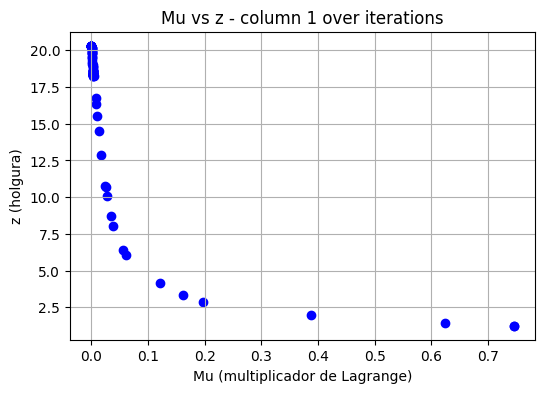

In [ ]:
graph_mu_vs_z_one_component(mudf,zdf,1)

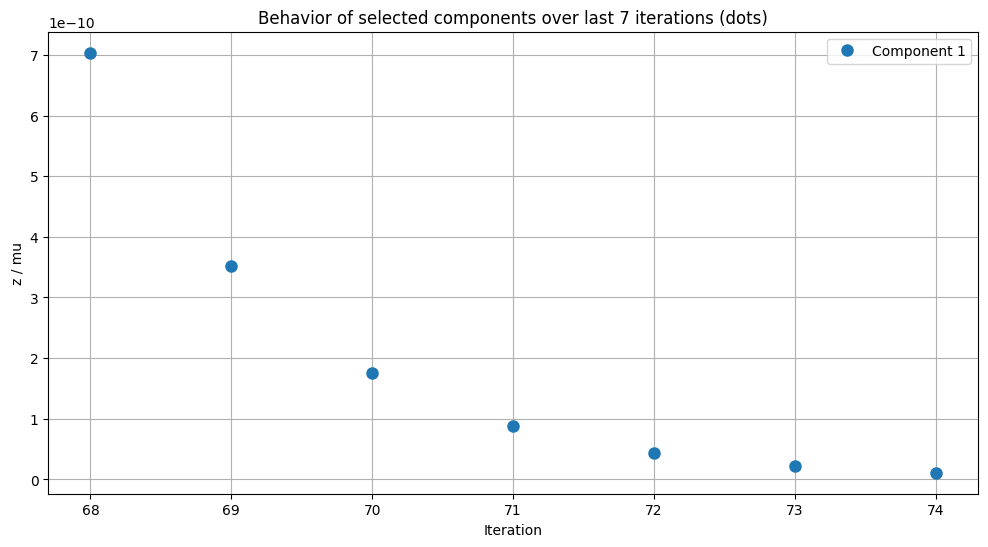

In [ ]:
graph_ratio_selected_components(muzdf,3,7,seed=42,indexes=[1])

In [67]:
cols_mu = find_components_tending_to_zero(mudf=mudf, threshold=1e-4, last_n_iters=5)
cols_z  = find_components_tending_to_zero(zdf=zdf, threshold=1e-4, last_n_iters=5)

all_cols = set(range(mudf.shape[1]))

cols_mu = set(cols_mu)
cols_z = set(cols_z)

neither = all_cols - (cols_mu | cols_z)

print(f"Components where neither mu nor z → 0: {len(neither)}")
print(f"indexes: {sorted(neither)}")

Components where mu only → 0 (threshold=0.0001, last 5 iters): 817
indexes selected = [0, 5, 6, 9, 12, 13, 14, 17, 19, 20, 23, 24, 27, 30, 33, 37, 38, 39, 42, 46, 47, 49, 50, 52, 53, 55, 56, 58, 61, 62, 64, 65, 67, 68, 70, 71, 73, 74, 75, 79, 80, 81, 85, 86, 88, 89, 90, 93, 97, 98, 99, 102, 106, 107, 109, 110, 112, 113, 114, 117, 121, 122, 123, 126, 129, 133, 134, 135, 139, 140, 141, 147, 151, 152, 153, 157, 158, 160, 161, 162, 165, 168, 171, 175, 176, 177, 180, 184, 185, 187, 188, 189, 193, 194, 196, 199, 200, 201, 204, 207, 210, 214, 215, 217, 218, 219, 223, 224, 226, 227, 229, 230, 231, 234, 237, 240, 244, 245, 247, 248, 249, 253, 254, 256, 257, 258, 261, 264, 267, 270, 274, 275, 277, 278, 279, 282, 285, 289, 290, 292, 293, 294, 298, 299, 300, 303, 306, 309, 313, 314, 315, 319, 320, 321, 325, 326, 328, 329, 330, 334, 335, 336, 340, 341, 342, 345, 348, 352, 353, 354, 358, 359, 361, 362, 364, 365, 366, 369, 372, 375, 378, 382, 383, 384, 388, 389, 390, 393, 396, 400, 401, 403, 404, 406

In [66]:
find_components_tending_to_zero(mudf, zdf,
                                       threshold=0.1,
                                       last_n_iters=3)

Components where mu AND z → 0 (threshold=0.1, last 3 iters): 8
indexes selected = [8, 145, 482, 561, 662, 749, 977, 1145]


[8, 145, 482, 561, 662, 749, 977, 1145]

In [52]:
mudf.shape[1]

1677